```text
Case-Study: Mortgages (Germany)
├── Import & Setup
├── Loading
├── Exploring
├── Modelling
│   ├── Pre-processing
│   └── Models  
│            └──Structural
│            └──Structural-Behavioural            
└── Policies
    ├── Define policies
    └── Quantify impact
```

#### Import & Setup

In [1]:
# Init work dir

from pathlib import Path
import sys

# Credit-Risk-Framework
PROJECT_ROOT = Path("/Users/konstantinoskazanas/Downloads/DATA SCIENCE/CREDIT-RISK-FRAMEWORK")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Mortgage case-study
WORK_DIR = Path.cwd()

In [2]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.decisioning import aggregate_dr_on_years
from src.feature_engineering import SpecialMappingsMortgage, handle_missing_values
from src.metrics import my_metrics
from src.modelling import estimate_capital
from src.plots import my_dr_plot, plot_distribution_by_category, show_correlation, plot_pie_chart
from src.preprocessing import my_time_split
from src.validation import missing_summary

# ML modules

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import xgboost

#### Loading

In [ ]:
# join excel files, drop NA columns, keep Germany

dataset1 = pd.read_excel('../Case Study Dataset/Case Study_dataset 1.xlsx')
dataset2 = pd.read_excel('../Case Study Dataset/Case Study_dataset 2.xlsx')
ds       = pd.concat([dataset1, dataset2], ignore_index=True)
ds       = ds.dropna(axis=1, how="all")
ds       = ds[(ds["CountryOfOrigination"].isin(["Germany"])) & (ds["ProductName"].isin(["General mortgages"]))]
ds       = ds.drop(columns=["CountryOfOrigination", "City", "ProductName"])
print(len(ds))         # Germany & General mortgages: 64.293
#print(ds.info())

64293
<class 'pandas.DataFrame'>
Index: 64293 entries, 2 to 123679
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Nr                          64293 non-null  int64         
 1   DateOfObservation           64293 non-null  datetime64[us]
 2   Loan_ID                     64293 non-null  int64         
 3   Client_ID                   64293 non-null  int64         
 4   DefaultFlag                 64293 non-null  int64         
 5   PropertyType                64293 non-null  str           
 6   PropertyValue               64293 non-null  int64         
 7   PropertySize                64293 non-null  float64       
 8   ExposureLoanToValue         64293 non-null  float64       
 9   TotalCustomerLoanToValue    64293 non-null  float64       
 10  NumberOfExposures           64293 non-null  int64         
 11  ExposureAmount              64293 non-null  int64         
 12 

#### Exploring 

##### Distribution by category

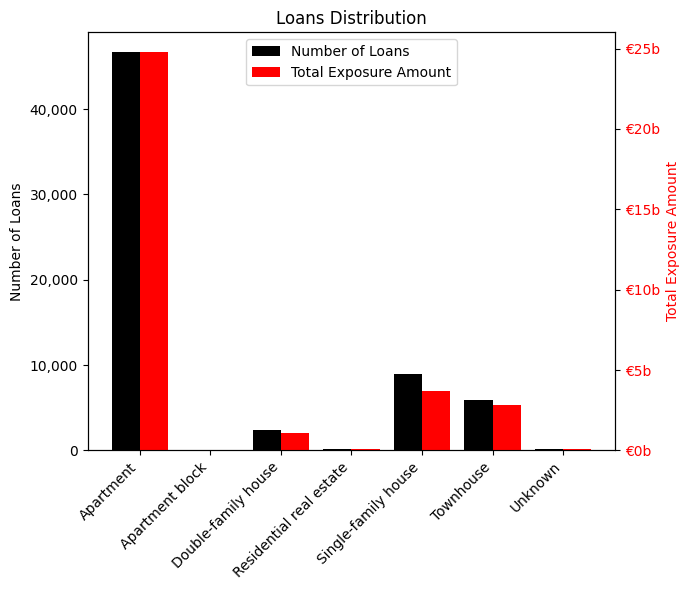

In [4]:
plot_distribution_by_category(ds, category="PropertyType", exposure_column="ExposureAmount")

##### Default Rate per year

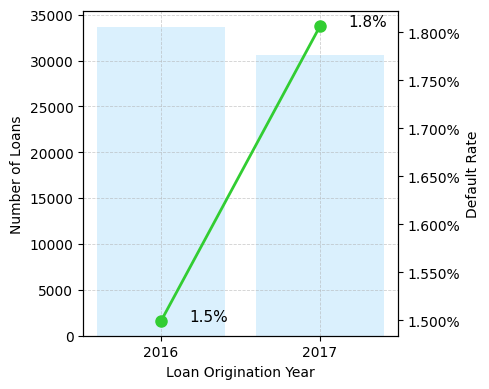

DR (overall):  0.01645591277433002


In [5]:
# plot DR 

dr_summary = aggregate_dr_on_years(ds, "DateOfObservation", "DefaultFlag")
my_dr_plot(dr_summary, 2016, 2017)
print('DR (overall): ', ds["DefaultFlag"].mean())

##### LTV

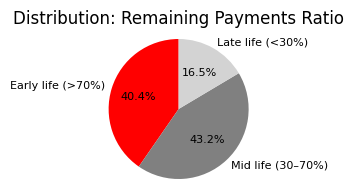

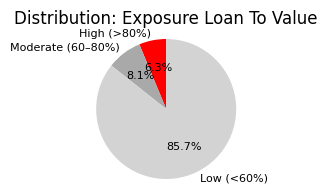

In [6]:
# plot pies

plot_pie_chart(ds, "RemainingPaymentsRatio")
plot_pie_chart(ds, "ExposureLoanToValue")

##### Explore variables

In [7]:
# 1. Target
ds["DefaultFlag"].value_counts(normalize=True)

DefaultFlag
0    0.983544
1    0.016456
Name: proportion, dtype: float64

In [8]:
# 2. Dates
ds["DateOfObservation"].min(), ds["DateOfObservation"].max()

(Timestamp('2016-01-31 00:00:00'), Timestamp('2017-12-31 00:00:00'))

In [9]:
# 4. Behavioural variables
ds[
    [
        "DelinquencyFlag",
        "DaysInDelinquency",
        "ExposureDefaultFlagCount",
        "ClientDefaultFlagCount"
    ]
].describe()

,DelinquencyFlag,DaysInDelinquency,ExposureDefaultFlagCount,ClientDefaultFlagCount
count,64293.000000,64293.000000,64293.000000,64293.000000
mean,0.076680,2.300546,0.190783,0.263886
std,0.266085,9.567210,0.666242,0.775056
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000
max,1.000000,119.000000,13.000000,13.000000


In [10]:
# 5. loan uniqueness
print(ds.groupby("Loan_ID").size().describe())
print(ds["Loan_ID"].nunique())

count    62042.000000
mean         1.036282
std          0.191674
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          3.000000
dtype: float64
62042


In [11]:
# 6. client uniqueness
print(ds.groupby("Client_ID").size().describe())
print(ds["Client_ID"].nunique())

count    62021.000000
mean         1.036633
std          0.192690
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          4.000000
dtype: float64
62021


In [12]:
# 7. observational frequency
ds.groupby(
    ds["DateOfObservation"].dt.to_period("M")
)["DefaultFlag"].agg(["count", "sum", "mean"])

,count,sum,mean
DateOfObservation,,,
2016-01,2126,47,0.022107
2016-02,2394,41,0.017126
2016-03,2840,58,0.020423
2016-04,2374,41,0.017270
2016-05,2933,46,0.015684
2016-06,3037,58,0.019098
2016-07,3024,37,0.012235
2016-08,2806,30,0.010691
2016-09,3044,41,0.013469


## Modelling

### Pre-processing

##### Split

In [13]:
# split

windows = {"train": (2016, 2016), "test":  (2017, 2017)}

splits = my_time_split(ds, "LoanYear", windows, target="DefaultFlag")

X_trai = splits["train"]["X"]
y_trai = splits["train"]["y"]
X_test = splits["test"]["X"]
y_test = splits["test"]["y"]


SPLIT SUMMARY

TRAIN
Years        : 2016 - 2016
Shape (X, y) : (33681, 32), (33681,)

LoanYear distribution
LoanYear
2016    33681
Name: count, dtype: int64

Default rate : 0.0150
------------------------------------------------------------

TEST
Years        : 2017 - 2017
Shape (X, y) : (30612, 32), (30612,)

LoanYear distribution
LoanYear
2017    30612
Name: count, dtype: int64

Default rate : 0.0181
------------------------------------------------------------


##### Map categorical variables

In [14]:
# mapping not needed: set as category type

X_trai["PropertyType"] = X_trai["PropertyType"].astype("category")
X_test["PropertyType"] = X_test["PropertyType"].astype("category")

##### Missing values

In [15]:
# summary of missing values before imputation

print(' ')
print('missing values summary before imputation:')
print(missing_summary(X_trai))
print(missing_summary(X_test))

# HANDLE MISSING VALUES

X_trai, X_test = handle_missing_values(X_trai, X_test, do_not_handle=["Nr", "DateOfObservation", "Loan_ID", "Client_ID" ])

# summary of missing values after imputation

print(' ')
print('missing values summary after imputation:')
print(missing_summary(X_trai))
print(missing_summary(X_test))

 
missing values summary before imputation:
                            missing_count  missing_percent
DelinquencyLast3Mon                    42         0.124699
DelinquencyLast12Mon                   42         0.124699
30PlusDelinquencyLast3Mon              42         0.124699
30PlusDelinquencyLast12Mon             42         0.124699
60PlusDelinquencyLast3Mon              42         0.124699
60PlusDelinquencyLast12Mon             42         0.124699
0_30DelinquencyLast3Mon                42         0.124699
0_30DelinquencyLast12Mon               42         0.124699
30_60DelinquencyLast3Mon               42         0.124699
30_60DelinquencyLast12Mon              42         0.124699
60_90DelinquencyLast3Mon               42         0.124699
60_90DelinquencyLast12Mon              42         0.124699
                            missing_count  missing_percent
DelinquencyLast3Mon                    25         0.081667
DelinquencyLast12Mon                   24         0.078401
30PlusDelinq

##### Feature Groups

In [16]:
# features

features_struc = [
    "PropertyValue",
    "PropertySize",
    "ExposureLoanToValue",
    "TotalCustomerLoanToValue",
    "PropertyType",
    "ExposureAmount",
    "RemainingPaymentsRatio",
    "TimeToMaturity",
    "MaturityRatio",
    "InterestRate",
    "MonthsOnBook",
    "NumberOfExposures",
    ]

features_behav = [
    "DelinquencyFlag",
    "DelinquencyLast3Mon",
    "DelinquencyLast12Mon",
    "30PlusDelinquencyLast3Mon",
    "30PlusDelinquencyLast12Mon",
    "60PlusDelinquencyLast3Mon",
    "60PlusDelinquencyLast12Mon",
    "0_30DelinquencyLast3Mon",
    "0_30DelinquencyLast12Mon",
    "30_60DelinquencyLast3Mon",
    "30_60DelinquencyLast12Mon",
    "60_90DelinquencyLast3Mon",
    "60_90DelinquencyLast12Mon",
    "DaysInDelinquency",
    "ExposureDefaultFlagCount",
    "ClientDefaultFlagCount",
    ]

In [17]:
# describe

ds[features_behav].describe().T

,count,mean,std,min,25%,50%,75%,max
DelinquencyFlag,64293.0,0.076680,0.266085,0.0,0.0,0.0,0.0,1.0
DelinquencyLast3Mon,64226.0,0.284059,0.778393,0.0,0.0,0.0,0.0,3.0
DelinquencyLast12Mon,64227.0,1.193486,2.916863,0.0,0.0,0.0,0.0,12.0
30PlusDelinquencyLast3Mon,64226.0,0.117367,0.498144,0.0,0.0,0.0,0.0,3.0
30PlusDelinquencyLast12Mon,64227.0,0.522382,1.891675,0.0,0.0,0.0,0.0,12.0
60PlusDelinquencyLast3Mon,64226.0,0.049622,0.327080,0.0,0.0,0.0,0.0,3.0
60PlusDelinquencyLast12Mon,64227.0,0.263736,1.331534,0.0,0.0,0.0,0.0,12.0
0_30DelinquencyLast3Mon,64226.0,0.204216,0.616542,0.0,0.0,0.0,0.0,3.0
0_30DelinquencyLast12Mon,64227.0,0.813614,2.116635,0.0,0.0,0.0,0.0,12.0
30_60DelinquencyLast3Mon,64226.0,0.052673,0.307802,0.0,0.0,0.0,0.0,3.0


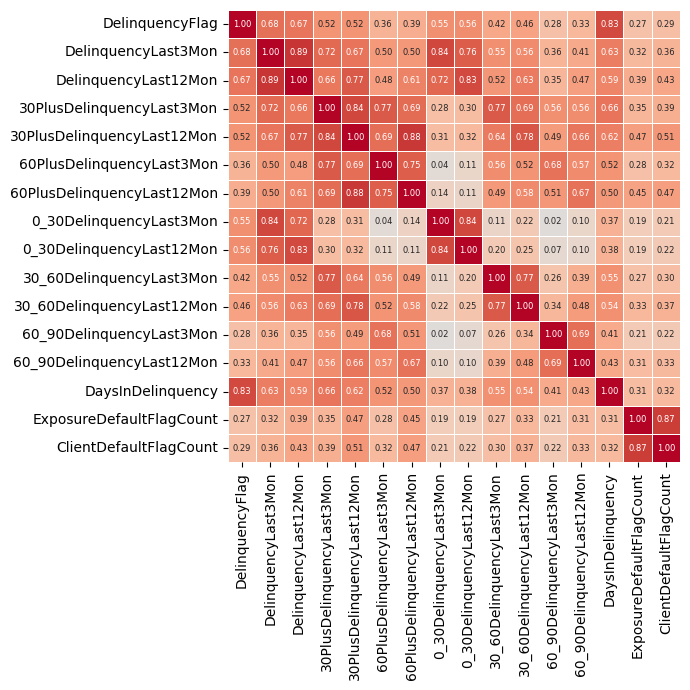


CORRELATION PAIRS ABOVE 0.8:
DelinquencyLast12Mon - DelinquencyLast3Mon: 0.89
30PlusDelinquencyLast12Mon - 30PlusDelinquencyLast3Mon: 0.84
60PlusDelinquencyLast12Mon - 30PlusDelinquencyLast12Mon: 0.88
0_30DelinquencyLast3Mon - DelinquencyLast3Mon: 0.84
0_30DelinquencyLast12Mon - DelinquencyLast12Mon: 0.83
0_30DelinquencyLast12Mon - 0_30DelinquencyLast3Mon: 0.84
DaysInDelinquency - DelinquencyFlag: 0.83
ClientDefaultFlagCount - ExposureDefaultFlagCount: 0.87


In [18]:
# correlation

show_correlation(ds[features_behav])

### Models: model A (structural) - model B (structural + behavioural)

In [19]:
# define model method

model_A = xgboost.XGBClassifier(random_state=888, max_depth=2, learning_rate=0.05, enable_categorical=True, tree_method="hist")
model_B = xgboost.XGBClassifier(random_state=888, max_depth=2, learning_rate=0.05, enable_categorical=True, tree_method="hist")


In [20]:
# MODEL A: reduce feature number

model_A.fit(X_trai[features_struc], y_trai)

# feature importance
importance = pd.Series(model_A.feature_importances_, index=X_trai[features_struc].columns)
# sort and take first 22
sorted = importance.sort_values(ascending=False)
# save feature names to list
features_A = sorted.head(22).index.tolist()
# print
print(features_A)

['TotalCustomerLoanToValue', 'ExposureAmount', 'ExposureLoanToValue', 'RemainingPaymentsRatio', 'InterestRate', 'PropertyValue', 'PropertyType', 'PropertySize', 'NumberOfExposures', 'TimeToMaturity', 'MonthsOnBook', 'MaturityRatio']


In [21]:
# MODEL A: fit

model_A.fit(X_trai[features_A], y_trai)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [22]:
# MODEL B: reduce feature number

model_B.fit(X_trai[features_struc + features_behav], y_trai)

# feature importance
importance = pd.Series(model_B.feature_importances_, index=X_trai[features_struc + features_behav].columns)
# sort and take first 22
sorted = importance.sort_values(ascending=False)
# save feature names to list
features_B = sorted.head(22).index.tolist()
# print
print(features_B)

['30PlusDelinquencyLast12Mon', 'DaysInDelinquency', '60PlusDelinquencyLast3Mon', 'DelinquencyLast3Mon', '60PlusDelinquencyLast12Mon', 'DelinquencyLast12Mon', 'ExposureDefaultFlagCount', '0_30DelinquencyLast12Mon', 'PropertyValue', 'RemainingPaymentsRatio', 'TotalCustomerLoanToValue', 'ExposureAmount', '0_30DelinquencyLast3Mon', 'ClientDefaultFlagCount', 'PropertyType', '30_60DelinquencyLast12Mon', 'ExposureLoanToValue', 'PropertySize', 'MonthsOnBook', 'TimeToMaturity', 'MaturityRatio', '30_60DelinquencyLast3Mon']


In [23]:
# MODEL B

model_B.fit(X_trai[features_B], y_trai)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [24]:
# PREDICTIONS

predictions_model_A_trai = model_A.predict_proba(X_trai[features_A])[:,1]
predictions_model_A_test = model_A.predict_proba(X_test[features_A])[:,1]
predictions_model_B_trai = model_B.predict_proba(X_trai[features_B])[:,1]
predictions_model_B_test = model_B.predict_proba(X_test[features_B])[:,1]

In [25]:
# METRICS

metrics_trai = my_metrics(y_trai, predictions_model_A_trai, exposure=X_trai["ExposureAmount"], dataset_name="Model A (TRAIN)", verbose=True)
metrics_test = my_metrics(y_test, predictions_model_A_test, exposure=X_test["ExposureAmount"], dataset_name="Model A (TEST)" , verbose=True)
print(" Δ GINI  :", (2 * metrics_trai["AUC"] - 1)-(2 * metrics_test["AUC"] - 1))

metrics_trai = my_metrics(y_trai, predictions_model_B_trai, exposure=X_trai["ExposureAmount"], dataset_name="Model B (TRAIN)", verbose=True)
metrics_test = my_metrics(y_test, predictions_model_B_test, exposure=X_test["ExposureAmount"], dataset_name="Model B (TEST)" , verbose=True)
print(" Δ GINI  :", (2 * metrics_trai["AUC"] - 1)-(2 * metrics_test["AUC"] - 1))


----------------------------------------
Model A (TRAIN)
----------------------------------------
AUC         : 0.7280
KS          : 0.3295
Observed DR : 1.50%
Mean PD     : 1.50%
Brier       : 0.0145
Exposure    : 17,291,660,207
----------------------------------------
----------------------------------------
Model A (TEST)
----------------------------------------
AUC         : 0.6441
KS          : 0.2430
Observed DR : 1.81%
Mean PD     : 1.32%
Brier       : 0.0177
Exposure    : 15,200,308,050
----------------------------------------
 Δ GINI  : 0.1678301128368913
----------------------------------------
Model B (TRAIN)
----------------------------------------
AUC         : 0.9367
KS          : 0.7546
Observed DR : 1.50%
Mean PD     : 1.50%
Brier       : 0.0112
Exposure    : 17,291,660,207
----------------------------------------
----------------------------------------
Model B (TEST)
----------------------------------------
AUC         : 0.8163
KS          : 0.5897
Observed DR : 1.81%

## Policies

### Define Policies

In [28]:
# Portfolio

portfolio = splits["test"]["df"]
portfolio["PD struc"] = predictions_model_A_test
portfolio["PD"]       = predictions_model_B_test
portfolio["LGD"]      = 0.4

In [29]:
# Policy 1: PD based 

policy_1 = portfolio[portfolio["PD"]<0.20]

# Policy 2: Exposure based 

policy_2 = portfolio[portfolio["ExposureLoanToValue"]<0.8]

# Policy 3: Combined 

policy_3 = portfolio[(portfolio["PD"]<0.20) & (portfolio["ExposureLoanToValue"]<0.8)]

# Policies

policies = {"POLICY 1": policy_1, "POLICY 2": policy_2, "POLICY 3": policy_3,}

### Quantify Impact

In [31]:
# impact: metrics + capital

policy_metrics = {}

for name, policy in policies.items():

    policy_metrics[name] = my_metrics(
        policy["DefaultFlag"],
        policy["PD"],
        exposure=policy["ExposureAmount"],
        dataset_name=name,
    )

    _, loss_summary, el_summary, _ = estimate_capital(policy, method="monte-carlo", column_lgd="LGD", column_def="DefaultFlag", column_ead="ExposureAmount", show_plot=False)
    el = el_summary["EL (MC-simulated)"]
    ec = loss_summary["Economic Capital"]
    print(f"Expected Loss    : {el:,.0f}")
    print(f"Economic Capital : {ec:,.0f}")

----------------------------------------
POLICY 1
----------------------------------------
AUC         : 0.7386
KS          : 0.4496
Observed DR : 1.24%
Mean PD     : 0.96%
Brier       : 0.0116
Exposure    : 14,756,657,233
----------------------------------------
Expected Loss    : 69,121,365
Economic Capital : 16,221,720
----------------------------------------
POLICY 2
----------------------------------------
AUC         : 0.8101
KS          : 0.5781
Observed DR : 1.73%
Mean PD     : 1.43%
Brier       : 0.0149
Exposure    : 13,148,544,250
----------------------------------------
Expected Loss    : 96,873,075
Economic Capital : 17,983,165
----------------------------------------
POLICY 3
----------------------------------------
AUC         : 0.7363
KS          : 0.4435
Observed DR : 1.22%
Mean PD     : 0.93%
Brier       : 0.0115
Exposure    : 12,830,898,620
----------------------------------------
Expected Loss    : 56,876,552
Economic Capital : 14,076,958
